In [81]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
from pydantic import BaseModel, Field
import os
from langgraph.graph import StateGraph, START, END
api_key = os.getenv("GOOGLE_API_KEY")

if os.environ['GOOGLE_API_KEY']:
    print("Google api key is set")
else:
    raise ValueError("Gemini API key is not set")


llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", google_api_key=api_key, temperature=0.7)

Google api key is set


In [ ]:
from langchain_core.tools import tool
import shutil

@tool
def create_file(name: str, file_path: str) -> str:
    """Tool for Creating new Files and Folders"""
    try:
        os.makedirs(file_path, exist_ok=True)

        full_path = os.path.join(file_path, name)

        with open(full_path, "w", encoding="utf-8") as f:
            pass

        return f"File created successfully at file path:{file_path}"
    
    except Exception as e:
        return f"Error: {e}"

@tool
def read_file(name: str, file_path: str) -> str:
    """Tool for Reading Files"""
    try:
        os.mkdirs(file_path, exist_ok=True)

        full_path = os.path.join(file_path, name)
        with open(full_path, "r", encoding="utf-8") as f:
            pass

        return f"File loaded successfully from file path:{file_path}"

    except Exception as e:
        return f"Error: {e}"

@tool
def write_file(name: str, file_path: str, content: str) -> str:
    """Tool for Writing into Files"""
    try:
        full_path = os.path.join(file_path, name)
        with open(full_path, "w", encoding="utf-8") as f:
            f.write(content)

        return f"File written successfully at file path:{file_path}"

    except Exception as e:
        return f"Error: {e}"

@tool
def move_file(source_path: str, destination_path: str):
    """
    Tool for moving Files or Folder from one location to another
    Args:
        source_path: Full path of the file or folder to move.
        destination_path: Destination directory or full destination path.
    """
    try:
        if not os.path.isdir(source_path):
            return f"Source does not exists {source_path}"

        if not os.path.isdir(destination_path):
            return f"Destination does not exists {destination_path}"

        new_path = shutil(source_path, destination_path)

        return f"Succesfully move to: {new_path}"

    except Exception as e:
        return f"Error: {e}"
    
@tool
def list_file(folder_path: str) -> str:
    """Tool for Listing all Files in a folder"""
    try:
        if not os.path.isdir(folder_path):
            return f"Error Folder not found: {folder_path}"

        items = os.listdir(folder_path)

        if not items:
            return f"Folder is empty: {folder_path}"

        output = []

        for item in items:

            full_path = os.path.join(folder_path, item)
            if os.path.isdir(full_path):
                output.append(f"item: {item}")
            else:
                output.append(f"item: {item}")

        return "\n".join(output)

    except Exception as e:
        return f"Error: {e}"

@tool
def rename_file(item_path: str, new_name: str):
    """
    Tool for Renaming Files
    
    Args:
        item_path: Full path of the file or folder.
        new_name: New name (not the full path).
    """
    try:
        if not os.path.exists(item_path):
            return f"Error: {item_path} does not exists"

        parent_directory = os.path.dirname(item_path)
        new_path = os.path.join(parent_directory, new_name)

        os.rename(item_path, new_path)

        return f"Successfully renamed to: {new_name}"

    except Exception as e:
        return f"Error: {e}"
@tool
def copy_file():
    """Tool for copying Files"""

@tool
def delete_file():
    """Tool for deleting Files"""

@tool
def search_file():
    """Tool for Searching Files"""

In [83]:
tools = [create_file, read_file, write_file, move_file, delete_file, rename_file, copy_file, search_file]

llm_with_tools = llm.bind_tools(tools)


In [84]:
from typing import TypedDict,List, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage
from langgraph.graph.message import add_messages

class graph_schema(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

In [85]:
def graph_node(state: graph_schema) -> graph_schema:
    message = state['messages']
    response = llm_with_tools.invoke(message)
    return {
        "messages": [response]
    }

def tool_node(state: graph_schema) -> graph_schema:
    message = state['messages']
    tools_by_name = {tool.name: tool for tool in tools}
    tool_result = []

    for tool_call in message[-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        result = tool.invoke(tool_call["args"])
        tool_result.append(ToolMessage(content=str(result), tool_call_id=tool_call["id"]))

    return {
        "messages": tool_result
    }

def if_tool_call(state: graph_schema) -> str:
    message = state['messages']

    if message[-1].tool_calls:
        return "tool_node"
    else:
        return "end"

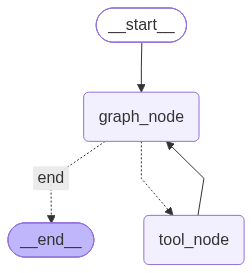

In [86]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("graph_node", graph_node)
graph.add_node("tool_node", tool_node)

graph.add_edge(START, "graph_node")
graph.add_conditional_edges("graph_node", if_tool_call, {"tool_node": "tool_node", "end": END})
graph.add_edge("tool_node", "graph_node")
graph.add_edge("graph_node", END)

file_graph = graph.compile()
file_graph

In [87]:
result = file_graph.invoke({"messages":[HumanMessage(content=r"Create a new folder named Secret_Folder at location inside C drive inside of folder Users then go fahee then go to OneDrive then go to Desktop")]})
result

{'messages': [HumanMessage(content='Create a new folder named Secret_Folder at location inside C drive inside of folder Users then go fahee then go to OneDrive then go to Desktop', additional_kwargs={}, response_metadata={}, id='df528ca5-7344-400a-be65-e2f87e314dd3'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'create_file', 'arguments': '{"name": "Secret_Folder", "file_path": "C:/Users/fahee/OneDrive/Desktop/Secret_Folder"}'}, '__gemini_function_call_thought_signatures__': {'9iNp39K4': 'EjQKMgERTTIPfrzk5TowDtRt49Yj8OJpfOIRIaWa2vAR8jGhb24fT3O0OqUcBKzrkOnJN1sK'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019fa4a5-7328-7330-bcc5-03b8443f3886-0', tool_calls=[{'name': 'create_file', 'args': {'name': 'Secret_Folder', 'file_path': 'C:/Users/fahee/OneDrive/Desktop/Secret_Folder'}, 'id': '9iNp39K4', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata